In [ ]:
"""Load example arrays from the repo and run Fill-Spill-Merge."""
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["OMP_DYNAMIC"] = "FALSE"

%load_ext autoreload
%autoreload 2
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")
DATA_DIR = REPO_ROOT / "examples" / "data"

# Make the repo package importable when running this script directly.
sys.path.insert(0, str(REPO_ROOT))
from fillspillmerge import fill_spill_merge

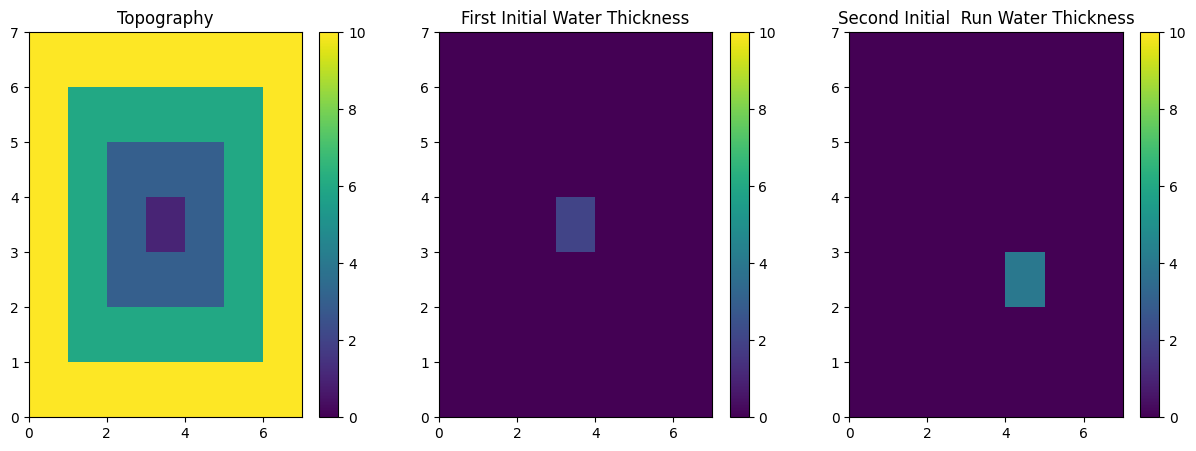

In [5]:
topography = np.loadtxt(DATA_DIR / "topography.csv", delimiter=",", dtype=np.float64)
in1 = np.zeros_like(topography); in1[3,3] = 2.0 #np.loadtxt(DATA_DIR / "wtd_initial.csv", delimiter=",", dtype=np.float64)
in2 = np.zeros_like(topography); in2[2,4] = 4.0 #np.loadtxt(DATA_DIR / "wtd_initial.csv", delimiter=",", dtype=np.float64)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("Topography")
im0 = axes[0].pcolormesh(topography, shading="auto", clim=(0, 10))
fig.colorbar(im0, ax=axes[0])   
axes[1].set_title("First Initial Water Thickness")
im1 = axes[1].pcolormesh(in1, shading="auto", clim=(0, 10))
fig.colorbar(im1, ax=axes[1])
axes[2].set_title("Second Initial  Run Water Thickness")
im2 = axes[2].pcolormesh(in2, shading="auto", clim=(0, 10))
fig.colorbar(im2, ax=axes[2])

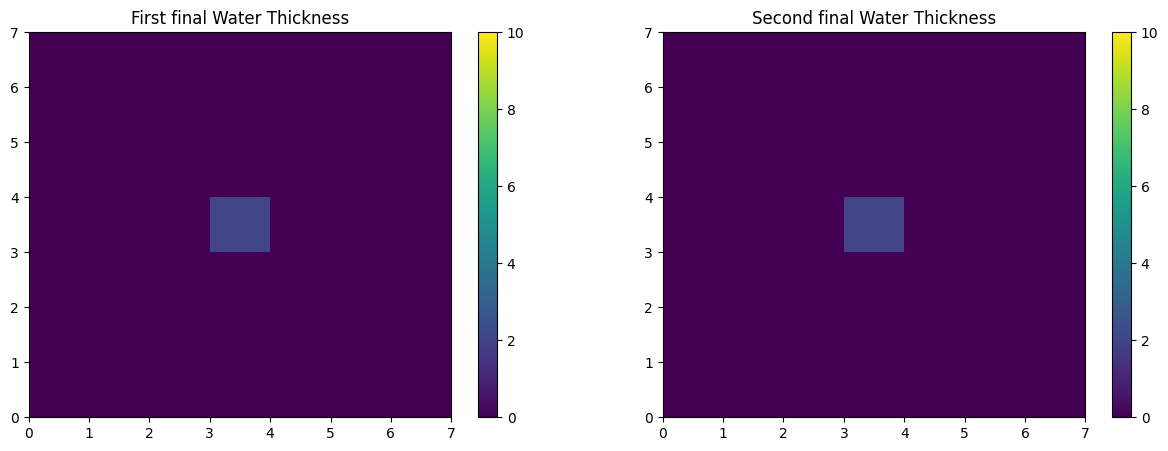

In [6]:
out1 = fill_spill_merge(
    wtd=in1,
    topography=topography,
    ocean_level=10.0,)
out2 = fill_spill_merge(
    wtd=in1,
    topography=topography,
    ocean_level=10.0,)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title("First final Water Thickness")
im0 = axes[0].pcolormesh(out1, shading="auto", clim=(0, 10))
fig.colorbar(im0, ax=axes[0])   
axes[1].set_title("Second final Water Thickness")
im1 = axes[1].pcolormesh(out2, shading="auto", clim=(0, 10))
fig.colorbar(im1, ax=axes[1])


In [7]:
import rioxarray

dem = rioxarray.open_rasterio("/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_bigger_3.tif", chunks={}).squeeze()
#add ocean cells around the edge of the DEM

coarsen_factor = 4
dem = dem[::coarsen_factor, ::coarsen_factor]
topography = dem.fillna(0).values
topography[0:1,:] = 0.0 
topography[-1:,:] = 0.0
topography[:,0:1] = 0.0
topography[:,-1:] = 0.0


In [8]:
dem.nbytes/1e6

1.048576

In [9]:
out, hier = fill_spill_merge(
    wtd=np.zeros_like(topography, dtype=np.float64),
    topography=topography,
    ocean_level=0.0,
    nodata=None,
    return_hierarchy=True,
)

In [10]:
import xarray_sweep as xs

wtd_temp = dem.copy()
def run_melt(m):
    melt = topography * 0 + m
    out1 = fill_spill_merge(wtd=melt, hierarchy=hier, nodata=None)
    wtd_temp.values = out1
    return wtd_temp

da_melt  = xs.xarray_sweep(run_melt, m = [1,2])
da_melt

/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 2/2 [00:00<00:00,  8.65it/s]


<xarray.DataArray (y: 1024, x: 256, m: 2)> Size: 4MB
array([[[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
...
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]]], shape=(1024, 256, 2))
Coordinates:
  * m        (m) int64 16B 1 2
Dimensions without coordinates: y, x
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

(np.float64(799940.0),
 np.float64(832708.0),
 np.float64(1868988.0),
 np.float64(2000060.0))

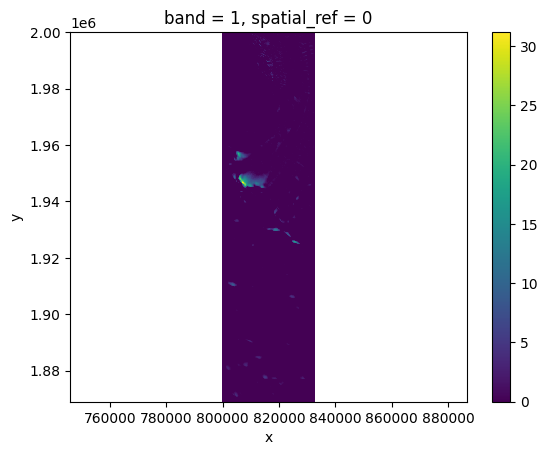

In [11]:
melt = topography * 0 + 1
out1 = fill_spill_merge(wtd=melt, hierarchy=hier, nodata=None)


wtd = dem.copy()
wtd.values = out1
# plt.pcolormesh(out1)
wtd.plot()
plt.axis("equal")


(np.float64(799940.0),
 np.float64(832708.0),
 np.float64(1868988.0),
 np.float64(2000060.0))

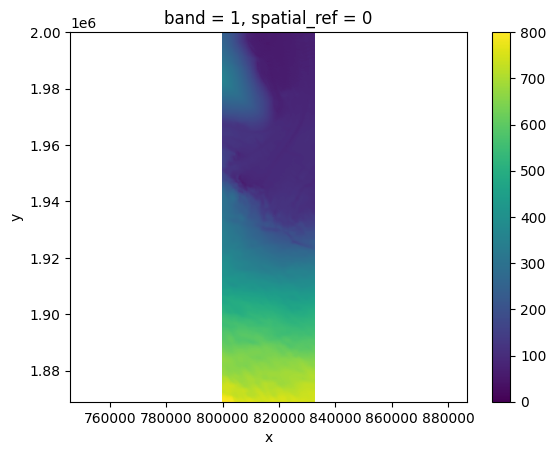

In [12]:
dem.plot()
plt.axis('equal')